In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
cd ..

C:\Users\aarus\Desktop\College\Projects\Credit-Risk-Decision-Engine


In [3]:
df = pd.read_csv('data/data_imputation_train.csv')
val_df = pd.read_csv('data/data_imputation_val.csv')
test_df = pd.read_csv('data/data_imputation_test.csv')

In [4]:
y_train = df['target']
X_train = df.drop(columns = ['target'])

y_val = val_df['target']
X_val = val_df.drop(columns = ['target'])

y_test = test_df['target']
X_test = test_df.drop(columns = ['target'])

In [5]:
def convert_ordinal_data(df):
    df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

    sub_grade_mapping = {
    'A1': 1, 'A2': 2, 'A3': 3, 'A4': 4, 'A5': 5,
    'B1': 6, 'B2': 7, 'B3': 8, 'B4': 9, 'B5': 10,
    'C1': 11, 'C2': 12, 'C3': 13, 'C4': 14, 'C5': 15,
    'D1': 16, 'D2': 17, 'D3': 18, 'D4': 19, 'D5': 20,
    'E1': 21, 'E2': 22, 'E3': 23, 'E4': 24, 'E5': 25,
    'F1': 26, 'F2': 27, 'F3': 28, 'F4': 29, 'F5': 30,
    'G1': 31, 'G2': 32, 'G3': 33, 'G4': 34, 'G5': 35
}
    df['sub_grade'] = df['sub_grade'].map(sub_grade_mapping)

    verif_mapping = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
    df['verification_status'] = df['verification_status'].map(verif_mapping)

    df['initial_list_status'] = (df['initial_list_status'] == 'w').astype(int)
    df['application_type'] = (df['application_type'] == 'Individual').astype(int)

    df = pd.get_dummies(df, columns=['home_ownership', 'purpose'], drop_first=True)

    return df

In [6]:
X_train = convert_ordinal_data(X_train)
X_val = convert_ordinal_data(X_val)
X_test = convert_ordinal_data(X_test)

In [7]:
# Using target encoder instead of one-hot-encoding to avoid creating 50 new columns
state_map = y_train.groupby(X_train['addr_state']).mean()
for df in [X_train, X_val, X_test]:
    df['state_risk_score'] = df['addr_state'].map(state_map)

X_train.drop(columns=['addr_state'], inplace=True)
X_val.drop(columns=['addr_state'], inplace=True)
X_test.drop(columns=['addr_state'], inplace=True)

In [8]:
# Aligning columns across dataset
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [11]:
def add_features(df):
    r = (df['int_rate'] / 100) / 12
    n = df['term']
    df['installment'] = df['loan_amnt'] * (r * (1 + r)**n) / ((1 + r)**n - 1)
    
    df['installment_to_inc'] = df['installment'] / (df['annual_inc'] / 12 + 1)
    df['loan_to_inc'] = df['loan_amnt'] / (df['annual_inc'] + 1)
    df['util_per_acc'] = df['revol_util'] / (df['open_acc'] + 1)
    df['interest_spread'] = df['int_rate'] - df['fed_funds_rate']
    
    return df

X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)

In [13]:
# Creating Financial Ratios (Run this on X_train, X_val, and X_test)
for df_set in [X_train, X_val, X_test]:
    # 1. How much of their monthly paycheck goes to this loan?
    df_set['installment_to_inc'] = df_set['installment'] / (df_set['annual_inc'] / 12 + 1)
    
    # 2. Total Debt burden relative to income
    df_set['total_debt_to_inc'] = (df_set['dti'] * df_set['annual_inc']) / 100
    
    # 3. Credit Utilization "Stress"
    # High util with few accounts is riskier than high util with many accounts
    df_set['util_per_acc'] = df_set['revol_util'] / (df_set['open_acc'] + 1)
    
    # 4. The "Risk Premium"
    # How much extra are they being charged over the Fed baseline?
    df_set['interest_spread'] = df_set['int_rate'] - df_set['fed_funds_rate']

    df_set['util_efficiency'] = df_set['revol_util'] / (df_set['total_rev_hi_lim'] + 1)
    df_set['debt_per_month_age'] = df_set['loan_amnt'] / (df_set['credit_hist_age_mths'] + 1)

print("Super Features created. New shape:", X_train.shape)

Super Features created. New shape: (1119711, 101)


In [14]:
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

In [15]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.03,      # Lower learning rate for better generalization
    'num_leaves': 64,           # Allow complex trees for the 1.1M rows
    'min_data_in_leaf': 200,    # Prevent overfitting on individual noise
    'scale_pos_weight': 3.5,    # Target the 80/20 imbalance precisely
    'feature_fraction': 0.8,    # Randomly select 80% of features for each tree
    'bagging_fraction': 0.8,    # Randomly select 80% of data for each tree
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42
}

In [19]:
lgbm_v3 = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,      
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1070]	train's auc: 0.769781	valid's auc: 0.731068


In [20]:
# Predict probabilities
probs = lgbm_v3.predict(X_val)

# Test a slightly higher threshold to boost Precision
# Since we used scale_pos_weight, 0.5 is already quite 'sensitive'
# Moving to 0.55 often provides a better profit margin for banks
custom_threshold = 0.55
preds = (probs >= custom_threshold).astype(int)

print(f"--- Results with Threshold {custom_threshold} ---")
print(classification_report(y_val, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_val, probs):.4f}")

--- Results with Threshold 0.55 ---
              precision    recall  f1-score   support

           0       0.86      0.70      0.77     70024
           1       0.39      0.62      0.48     21342

    accuracy                           0.69     91366
   macro avg       0.63      0.66      0.63     91366
weighted avg       0.75      0.69      0.71     91366

ROC-AUC Score: 0.7316


In [17]:
import shap

C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


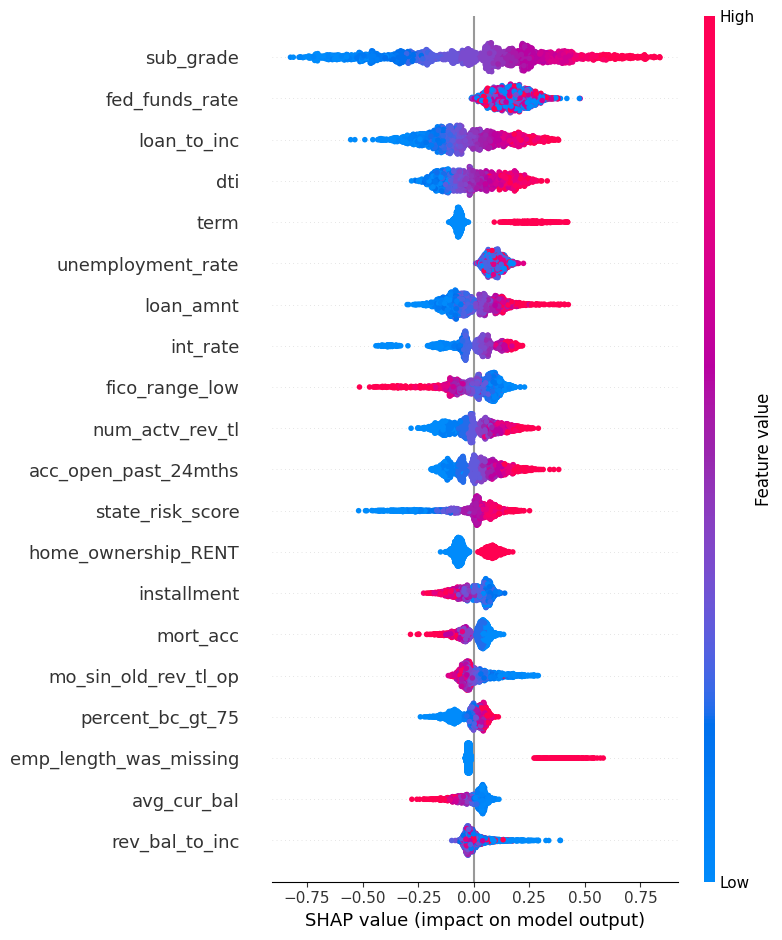

In [20]:
explainer = shap.TreeExplainer(lgbm_v3)

X_sample = X_val.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_sample)

In [21]:
import shap
import numpy as np

# 1. Initialize Explainer
explainer = shap.TreeExplainer(lgbm_v3)

# 2. Get values for a sample
X_sample = X_val.sample(2000, random_state=42)
shap_results = explainer.shap_values(X_sample)

# 3. Handle shape logic for the values
if isinstance(shap_results, list):
    # Older versions return a list [class 0, class 1]
    shap_to_plot = shap_results[1]
else:
    # Newer versions often return the array for class 1 directly
    shap_to_plot = shap_results

# 4. Handle shape logic for the expected value (The "Base Value")
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

# 5. Plot a specific borderline loan
# Let's pick a loan that is in your "Manual Review" bucket (prob around 0.5)
probs = lgbm_v3.predict(X_sample)
borderline_idx = np.abs(probs - 0.5).argmin() # Finds the loan closest to 0.5 probability

shap.initjs() # Load JS for the visualization
shap.force_plot(
    base_value, 
    shap_to_plot[borderline_idx, :], 
    X_sample.iloc[borderline_idx, :]
)

C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [22]:
import pandas as pd

# Calculate mean absolute SHAP values
vals = np.abs(shap_to_plot).mean(0)

# Create a DataFrame for easy analysis
feature_importance = pd.DataFrame(list(zip(X_sample.columns, vals)),
                                  columns=['col_name', 'feature_importance_vals'])

feature_importance.sort_values(by=['feature_importance_vals'], 
                               ascending=False, inplace=True)

# Print the top 20 and the bottom 20
print("--- TOP FEATURES (Keep These) ---")
print(feature_importance.head(20))

print("\n--- BOTTOM FEATURES (Potential Pruning) ---")
print(feature_importance.tail(20))

--- TOP FEATURES (Keep These) ---
                  col_name  feature_importance_vals
3                sub_grade                 0.290411
63          fed_funds_rate                 0.168413
95             loan_to_inc                 0.142522
6                      dti                 0.109953
1                     term                 0.109119
62       unemployment_rate                 0.093726
0                loan_amnt                 0.093445
2                 int_rate                 0.091119
8           fico_range_low                 0.088090
48         num_actv_rev_tl                 0.087045
37    acc_open_past_24mths                 0.084709
92        state_risk_score                 0.082593
78     home_ownership_RENT                 0.074072
93             installment                 0.057383
43                mort_acc                 0.053875
42    mo_sin_old_rev_tl_op                 0.052763
56        percent_bc_gt_75                 0.050304
68  emp_length_was_missing    

In [23]:
# Dropping bottom 20 features -
features_to_remove = feature_importance['col_name'].tail(20).tolist()
X_train_pruned = X_train.drop(columns=features_to_remove)
X_val_pruned = X_val.drop(columns=features_to_remove)
print(f"Shape of train: {X_train_pruned.shape}")
print(f"Shape of Val: {X_val_pruned.shape}")

Shape of train: (1119711, 81)
Shape of Val: (91366, 81)


In [24]:
dtrain = lgb.Dataset(X_train_pruned, label=y_train)
dval = lgb.Dataset(X_val_pruned, label=y_val, reference=dtrain)

lgbm_v3 = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,      
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)
# Predict probabilities
probs = lgbm_v3.predict(X_val_pruned)

# Test a slightly higher threshold to boost Precision
# Since we used scale_pos_weight, 0.5 is already quite 'sensitive'
# Moving to 0.55 often provides a better profit margin for banks


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1589]	train's auc: 0.782824	valid's auc: 0.732043


In [23]:
# Predict probabilities
probs = lgbm_v3.predict(X_val_pruned)

# Test a slightly higher threshold to boost Precision
# Since we used scale_pos_weight, 0.5 is already quite 'sensitive'
# Moving to 0.55 often provides a better profit margin for banks
custom_threshold = 0.55
preds = (probs >= custom_threshold).astype(int)

print(f"--- Results with Threshold {custom_threshold} ---")
print(classification_report(y_val, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_val, probs):.4f}")

--- Results with Threshold 0.55 ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.78     70024
           1       0.39      0.62      0.48     21342

    accuracy                           0.69     91366
   macro avg       0.63      0.67      0.63     91366
weighted avg       0.75      0.69      0.71     91366

ROC-AUC Score: 0.7320


In [25]:
!pip install optuna-integration[lightgbm]

  Using cached optuna_integration-4.7.0-py3-none-any.whl.metadata (12 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Using cached optuna_integration-4.7.0-py3-none-any.whl (99 kB)


In [51]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score

# 1. Re-create Datasets with the 'feature_pre_filter' set to False from the start
dtrain = lgb.Dataset(X_train_pruned, label=y_train, params={'feature_pre_filter': False})
dval = lgb.Dataset(X_val_pruned, label=y_val, reference=dtrain, params={'feature_pre_filter': False})

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'feature_pre_filter': False,  # Match the Dataset setting
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'learning_rate': 0.05
    }

    # 2. Train using the fixed Datasets
    model = lgb.train(
        param, 
        dtrain, 
        valid_sets=[dval], 
        callbacks=[
            lgb.early_stopping(stopping_rounds=50), 
            lgb.log_evaluation(period=0)
        ]
    )
    
    # 3. Predict and evaluate
    probs = model.predict(X_val_pruned)
    preds = (probs > 0.55).astype(int) # Using our best-performing threshold
    
    return f1_score(y_val, preds)

# 4. Execute the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n" + "="*30)
print(f"BEST F1 SCORE: {study.best_value:.4f}")
print("BEST HYPERPARAMETERS:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("="*30)

[I 2026-02-23 19:19:39,130] A new study created in memory with name: no-name-6b388873-62db-4d7a-9778-e5dffef0232f


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.720614


[I 2026-02-23 19:19:50,639] Trial 0 finished with value: 0.43611312885160625 and parameters: {'lambda_l1': 0.012397569451762418, 'lambda_l2': 0.3987049467100933, 'num_leaves': 190, 'feature_fraction': 0.4035877983233666, 'bagging_fraction': 0.5745399079559366, 'bagging_freq': 1, 'min_child_samples': 68, 'scale_pos_weight': 2.470514187999261}. Best is trial 0 with value: 0.43611312885160625.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.721091


[I 2026-02-23 19:19:58,422] Trial 1 finished with value: 0.2719086162794772 and parameters: {'lambda_l1': 2.8553968218756354, 'lambda_l2': 0.21962335285666365, 'num_leaves': 140, 'feature_fraction': 0.6958801384897484, 'bagging_fraction': 0.5799974559013392, 'bagging_freq': 5, 'min_child_samples': 98, 'scale_pos_weight': 1.4558716921211023}. Best is trial 0 with value: 0.43611312885160625.


...

Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.721093
Training until validation scores don't improve for 50 rounds


[I 2026-02-23 19:27:05,231] Trial 48 finished with value: 0.4609163313900977 and parameters: {'lambda_l1': 1.2917319154453801e-05, 'lambda_l2': 3.04445774804297e-05, 'num_leaves': 217, 'feature_fraction': 0.7125681857044658, 'bagging_fraction': 0.5459461828214335, 'bagging_freq': 1, 'min_child_samples': 69, 'scale_pos_weight': 2.8635218028581857}. Best is trial 45 with value: 0.4748030426514534.


Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.722351
Training until validation scores don't improve for 50 rounds


[I 2026-02-23 19:27:15,024] Trial 49 finished with value: 0.4703736800831616 and parameters: {'lambda_l1': 1.3626344815920132e-05, 'lambda_l2': 0.0008585545783289038, 'num_leaves': 242, 'feature_fraction': 0.6440030714689313, 'bagging_fraction': 0.5239922203321483, 'bagging_freq': 2, 'min_child_samples': 83, 'scale_pos_weight': 3.340455762232767}. Best is trial 45 with value: 0.4748030426514534.


Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.721183

BEST F1 SCORE: 0.4748
BEST HYPERPARAMETERS:
  lambda_l1: 0.0010667723758705989
  lambda_l2: 0.00018415364860896262
  num_leaves: 201
  feature_fraction: 0.7215781474753609
  bagging_fraction: 0.6143687912484664
  bagging_freq: 3
  min_child_samples: 50
  scale_pos_weight: 3.6589714073378365


In [29]:
# The Final Hyperparameters from your Optuna Study
dtrain = lgb.Dataset(X_train_pruned, label=y_train, params={'feature_pre_filter': False})
dval = lgb.Dataset(X_val_pruned, label=y_val, reference=dtrain, params={'feature_pre_filter': False})

final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'feature_pre_filter': False,
    'lambda_l1': 0.0010667723758705989,
    'lambda_l2': 0.00018415364860896262,
    'num_leaves': 201,
    'feature_fraction': 0.7215781474753609,
    'bagging_fraction': 0.6143687912484664,
    'bagging_freq': 3,
    'min_child_samples': 50,
    'scale_pos_weight': 3.6589714073378365,
    'learning_rate': 0.05
}

final_lgbm_model = lgb.train(
    final_params,
    dtrain, 
    num_boost_round=1000, 
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# lgbm_v3 = lgb.train(
#     params,
#     dtrain,
#     num_boost_round=2000,      
#     valid_sets=[dtrain, dval],
#     valid_names=['train', 'valid'],
#     callbacks=[lgb.early_stopping(stopping_rounds=50)]
# )

# Save the model to a file
# import joblib
# joblib.dump(final_lgbm_model, 'final_credit_risk_model.joblib')
# print("Model Finalized and Saved.")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[329]	train's auc: 0.78907	valid's auc: 0.728405


In [53]:
# Predict probabilities
probs = final_lgbm_model.predict(X_val_pruned)

# Test a slightly higher threshold to boost Precision
# Since we used scale_pos_weight, 0.5 is already quite 'sensitive'
# Moving to 0.55 often provides a better profit margin for banks
# custom_threshold = 0.55
# preds = (probs >= custom_threshold).astype(int)

# print(f"--- Results with Threshold {custom_threshold} ---")
print(classification_report(y_val, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_val, probs):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.71      0.78     70024
           1       0.39      0.62      0.48     21342

    accuracy                           0.69     91366
   macro avg       0.63      0.67      0.63     91366
weighted avg       0.75      0.69      0.71     91366

ROC-AUC Score: 0.7291


In [41]:
import pandas as pd
import numpy as np

# 1. Define the Decision Logic
def classify_loan(p):
    if p < 0.30: # Very Low Risk
        return 'AUTO-ACCEPT (Green)'
    elif p > 0.65: # Very High Risk
        return 'AUTO-REJECT (Red)'
    else: # The "Gray Area"
        return 'MANUAL REVIEW (Gray)'

# 2. Create a Results DataFrame
results_df = pd.DataFrame({
    'Probability': probs,
    'Actual': y_val.values
})
results_df['Decision'] = results_df['Probability'].apply(classify_loan)

# 3. Calculate Business Metrics
stats = results_df.groupby('Decision').agg(
    Total_Loans=('Actual', 'count'),
    Defaults_Caught=('Actual', 'sum'),
    Default_Rate=('Actual', 'mean')
).reset_index()

# 4. Calculate Percentage of Portfolio
stats['%_of_Portfolio'] = (stats['Total_Loans'] / len(results_df) * 100).round(2)
stats['Default_Rate'] = (stats['Default_Rate'] * 100).round(2)

print("--- FINAL BUSINESS STRATEGY RESULTS ---")
print(stats)

--- FINAL BUSINESS STRATEGY RESULTS ---
               Decision  Total_Loans  Defaults_Caught  Default_Rate  \
0   AUTO-ACCEPT (Green)        21057             1306          6.20   
1     AUTO-REJECT (Red)        18698             8660         46.32   
2  MANUAL REVIEW (Gray)        51611            11376         22.04   

   %_of_Portfolio  
0           23.05  
1           20.46  
2           56.49  
